Convolution Match Location: (np.int64(13), np.int64(0))
Correlation Match Location: (np.int64(60), np.int64(36))


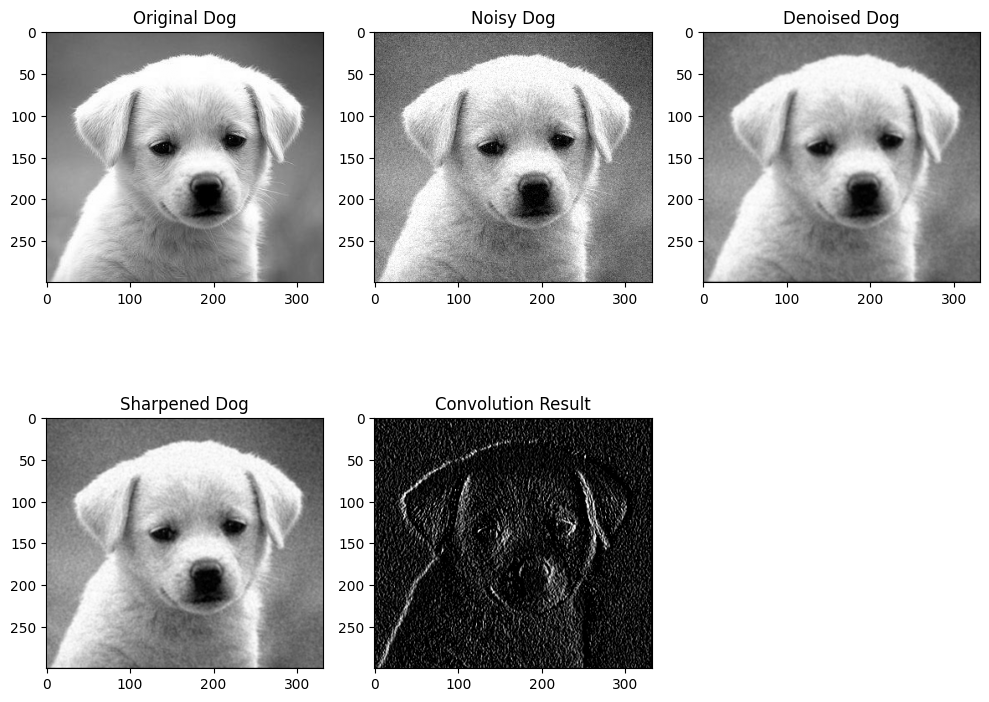

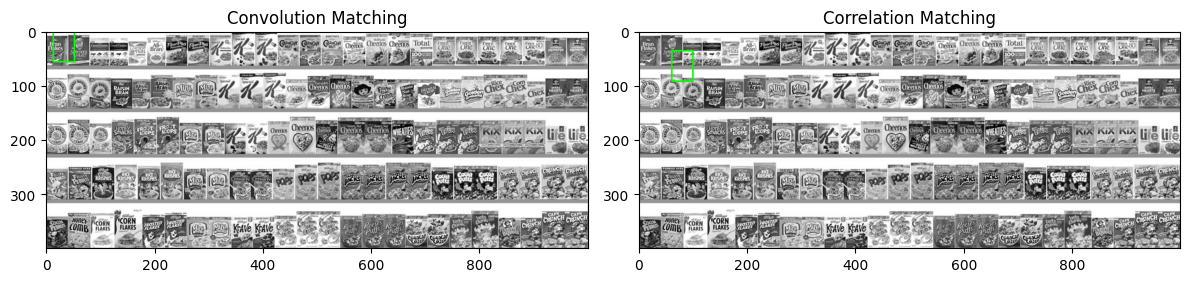

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def gaussian_noise(image, mean=0, std=15):
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)


def convolution(image, kernel):
    image = image.astype(np.float32)

    image_h, image_w = image.shape
    kernel_h, kernel_w = kernel.shape

    pad_h = kernel_h // 2
    pad_w = kernel_w // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    flipped_kernel = np.flipud(np.fliplr(kernel))

    output = np.zeros((image_h, image_w), dtype=np.float32)

    for i in range(image_h):
        for j in range(image_w):
            region = padded[i:i+kernel_h, j:j+kernel_w]
            output[i, j] = np.sum(region * flipped_kernel)

    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)


def gaussian_kernel(size=7, sigma=1.0):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel


def sharpening_kernel():
    kernel = np.array([
        [1, 4, 6, 4, 1],
        [4,16,24,16,4],
        [6,24,-476,24,6],
        [4,16,24,16,4],
        [1, 4, 6, 4, 1]
    ]) * (-1.0 / 256.0)
    return kernel


def template_matching_convolution(image, template):
    image = image.astype(np.float32)
    template = template.astype(np.float32)

    template = template - np.mean(template)
    image = image - np.mean(image)

    kernel = np.flipud(np.fliplr(template))

    return convolution(image, kernel)


def template_matching_correlation(image, template):
    image = image.astype(np.float32)
    template = template.astype(np.float32)

    template = template - np.mean(template)
    image = image - np.mean(image)

    image_h, image_w = image.shape
    temp_h, temp_w = template.shape

    output = np.zeros((image_h, image_w), dtype=np.float32)

    pad_h = temp_h // 2
    pad_w = temp_w // 2

    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    for i in range(image_h):
        for j in range(image_w):
            region = padded[i:i+temp_h, j:j+temp_w]
            output[i, j] = np.sum(region * template)

    return output


def find_best_match(result):
    y, x = np.unravel_index(np.argmax(result), result.shape)
    return (x, y)


def draw_rectangle(image, top_left, template_shape):
    h, w = template_shape
    image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    x, y = top_left
    cv2.rectangle(image_color, (x, y), (x + w, y + h), (0, 255, 0), 2)

    return image_color


def main():

    # Dog Image Part
    dog = cv2.imread('dog.jpg', cv2.IMREAD_GRAYSCALE)

    noisy_dog = gaussian_noise(dog)

    sobel_kernel = np.array([
        [1, 0, -1],
        [2, 0, -2],
        [1, 0, -1]
    ])

    conv_result = convolution(noisy_dog, sobel_kernel)

    gauss_kernel = gaussian_kernel(7, 1.0)
    denoised_dog = convolution(noisy_dog, gauss_kernel)

    sharp_kernel = sharpening_kernel()
    sharpened_dog = convolution(denoised_dog, sharp_kernel)


    # Template Matching Part
    shelf = cv2.imread('shelf.jpg', cv2.IMREAD_GRAYSCALE)
    template = cv2.imread('template.jpg', cv2.IMREAD_GRAYSCALE)

    conv_match = template_matching_convolution(shelf, template)
    corr_match = template_matching_correlation(shelf, template)

    conv_loc = find_best_match(conv_match)
    corr_loc = find_best_match(corr_match)

    conv_img = draw_rectangle(shelf, conv_loc, template.shape)
    corr_img = draw_rectangle(shelf, corr_loc, template.shape)


    print("Convolution Match Location:", conv_loc)
    print("Correlation Match Location:", corr_loc)

    # Display Dog Images
    plt.figure(figsize=(10,8))

    plt.subplot(2,3,1)
    plt.title("Original Dog")
    plt.imshow(dog, cmap='gray')

    plt.subplot(2,3,2)
    plt.title("Noisy Dog")
    plt.imshow(noisy_dog, cmap='gray')

    plt.subplot(2,3,3)
    plt.title("Denoised Dog")
    plt.imshow(denoised_dog, cmap='gray')

    plt.subplot(2,3,4)
    plt.title("Sharpened Dog")
    plt.imshow(sharpened_dog, cmap='gray')

    plt.subplot(2,3,5)
    plt.title("Convolution Result")
    plt.imshow(conv_result, cmap='gray')

    plt.tight_layout()
    plt.show()


    # Display Template Matching
    plt.figure(figsize=(12,6))

    plt.subplot(1,2,1)
    plt.title("Convolution Matching")
    plt.imshow(cv2.cvtColor(conv_img, cv2.COLOR_BGR2RGB))

    plt.subplot(1,2,2)
    plt.title("Correlation Matching")
    plt.imshow(cv2.cvtColor(corr_img, cv2.COLOR_BGR2RGB))

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

Correlation provides more accurate detection of the target object, because it compares the template directly with regions of the image without altering its orientation, hence preserving the structural features of the object. While, convolution involves flipping the template both horizontally and vertically before performing the operation, which may reduce the accuracy of detection in template matching tasks where orientation is important.

Correlation is also slightly more efficient and easier to implement, as it does not require the additional step of flipping the template. Although both methods have similar computational complexity, correlation is more straightforward and practical for this specific application.
